In [2]:
import numpy as np
import pandas as pd

import mne
from mne.datasets import eegbci

from mne_connectivity import spectral_connectivity_epochs

import networkx as nx

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

import matplotlib.pyplot as plt

mne.set_log_level("WARNING")
RANDOM_STATE = 42


In [3]:
subjects = list(range(1,11))  #subjects 1-10
run_id = 1                    # Run 1 is the baseline eyes open

epoch_len = 2.0               #seconds for each epoch
alpha_band = (8.0, 13.0)      #Hz

#Connectivity detials
method = "coh"                #coherence
mode = "multitaper"           #spectral estimation method
top_k = 60                    #keeps the strongest 60 edges per epoch

#preprocessing
l_freq = 1.0
h_freq = 40.0

In [4]:
#download and load only one subject data 
subj = 1 

#download edf files
fnames = eegbci.load_data(subj, runs=[run_id])  
#loads eeg into an mne raw object
raw = mne.io.read_raw_edf(fnames[0], preload = True, verbose = False)

#clean naming to ensure its standardized
raw.rename_channels(lambda x: x.strip(".")) 
#add the electrode positions for a standard 10-20 layout
raw.set_montage("standard_1020", on_missing="ignore")

<RawEDF | S001R01.edf, 64 x 9760 (61.0 s), ~4.8 MiB, data loaded>

In [5]:
raw.filter(l_freq, h_freq, fir_design="firwin", verbose=False)
raw.set_eeg_reference("average", verbose=False)

picks = mne.pick_types(raw.info, eeg=True, exclude="bads")
raw.pick(picks)

epochs = mne.make_fixed_length_epochs(raw, duration=epoch_len, overlap=0.0, preload=True, verbose=False)

epochs

<Epochs | 30 events (all good), 0 – 1.994 s (baseline off), ~4.8 MiB, data loaded,
 '1': 30>

In [6]:
con = spectral_connectivity_epochs(
    epochs,
    method = "coh",
    mode = "multitaper",
    sfreq=epochs.info["sfreq"],
    fmin = 8.0,
    fmax = 13.0,
    faverage = True,     #averages coherence across frequencies 8-13Hz to get only one value per channel pair per epoch
    verbose = False,
)

conn = con.get_data(output="dense")
conn.shape

print(epochs.ch_names)

['Fc5', 'Fc3', 'Fc1', 'Fcz', 'Fc2', 'Fc4', 'Fc6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'Cp5', 'Cp3', 'Cp1', 'Cpz', 'Cp2', 'Cp4', 'Cp6', 'Fp1', 'Fpz', 'Fp2', 'Af7', 'Af3', 'Afz', 'Af4', 'Af8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'Ft7', 'Ft8', 'T7', 'T8', 'T9', 'T10', 'Tp7', 'Tp8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'Po7', 'Po3', 'Poz', 'Po4', 'Po8', 'O1', 'Oz', 'O2', 'Iz']


In [7]:
def topk_graph_features(mat, ch_names, top_k=60, nodes=("C3", "C4")):
    """
    Convert one epoch's connectivity matrix into a small feature vector.

    mat: connectivity for ONE epoch.
         Expected to represent channel-by-channel connectivity.
         We will coerce it into a 2D (n_ch, n_ch) matrix safely.
    """

    # ---- 1) Force mat to be a 2D square matrix ----
    mat = np.asarray(mat)
    mat = np.squeeze(mat)  # turns (n,n,1) -> (n,n)

    if mat.ndim != 2:
        raise ValueError(f"Expected a 2D matrix after squeeze, got shape {mat.shape}")

    if mat.shape[0] != mat.shape[1]:
        raise ValueError(f"Expected a square matrix, got shape {mat.shape}")

    n = mat.shape[0]
    if n < 2:
        raise ValueError(
            f"Need at least 2 EEG channels to build a graph; got n={n}. "
            "This usually means your channel types weren't set and pick_types kept only one channel."
        )

    # Copy so we can edit safely
    m = mat.copy()

    # ---- 2) Remove diagonal ----
    # Connectivity of a channel with itself isn't meaningful for our graph edges.
    np.fill_diagonal(m, 0.0)

    # ---- 3) Extract unique edges (upper triangle) ----
    # Connectivity is symmetric: (i,j) == (j,i), so we only keep i<j.
    iu = np.triu_indices(n, k=1)     # pair of index arrays
    w = m[iu]                        # weights for each (i,j) pair, 1D vector length ~ n(n-1)/2

    # Handle NaNs/infs if any
    valid = np.isfinite(w)
    w = w[valid]
    iu_valid = (iu[0][valid], iu[1][valid])

    if w.size == 0:
        # No usable edges; return zeros
        feats = {
            "mean_degree": 0.0,
            "median_degree": 0.0,
            "mean_clustering": 0.0,
            "median_clustering": 0.0,
        }
        for node in nodes:
            feats[f"degree_{node}"] = 0.0
            feats[f"clustering_{node}"] = 0.0
        return feats

    # ---- 4) Select top-k strongest connections ----
    # This controls graph density: each epoch gets the same number of edges.
    k = min(top_k, w.size)
    top_idx = np.argpartition(w, -k)[-k:]  # indices of k largest weights (order not important)

    edges = []
    for idx in top_idx:
        i = int(iu_valid[0][idx])
        j = int(iu_valid[1][idx])
        weight = float(w[idx])
        edges.append((i, j, weight))

    # ---- 5) Build graph ----
    # Nodes: channels. Edges: strong connections.
    G = nx.Graph()
    G.add_nodes_from(range(n))
    G.add_weighted_edges_from(edges)

    # ---- 6) Degree (weighted) ----
    # Weighted degree ("strength") = sum of weights connected to node.
    degree = np.array([d for _, d in G.degree(weight="weight")], dtype=float)

    # ---- 7) Clustering coefficient ----
    # Unweighted clustering: triangle density around each node.
    # (Interpretable + usually stable for this use.)
    clustering_dict = nx.clustering(G)
    clust_vals = np.array([clustering_dict[i] for i in range(n)], dtype=float)

    # ---- 8) Aggregate into features ----
    feats = {
        "mean_degree": float(degree.mean()),
        "median_degree": float(np.median(degree)),
        "mean_clustering": float(clust_vals.mean()),
        "median_clustering": float(np.median(clust_vals)),
    }

    # Optional: specific electrodes like C3/C4
    name_to_idx = {nm: i for i, nm in enumerate(ch_names)}
    for node in nodes:
        if node in name_to_idx:
            idx = name_to_idx[node]
            feats[f"degree_{node}"] = float(degree[idx])
            feats[f"clustering_{node}"] = float(clust_vals[idx])
        else:
            feats[f"degree_{node}"] = 0.0
            feats[f"clustering_{node}"] = 0.0

    return feats


In [8]:
rows = []

for subj in subjects:
    print(f"\nLoading subject {subj} ...")

    # ---- Load raw EEG ----
    fnames = eegbci.load_data(subj, runs=[run_id])
    raw = mne.io.read_raw_edf(fnames[0], preload=True, verbose=False)

    # ---- Standardize metadata / channels ----
    raw.rename_channels(lambda x: x.strip("."))
    eegbci.standardize(raw)
    raw.set_montage("standard_1020", on_missing="ignore")

    # ---- Preprocess ----
    raw.filter(l_freq, h_freq, fir_design="firwin", verbose=False)
    raw.set_eeg_reference("average", verbose=False)

    # Keep EEG channels only
    picks = mne.pick_types(raw.info, eeg=True, exclude="bads")
    raw.pick(picks)

    # ---- Epoch into fixed windows (each epoch = one ML sample) ----
    epochs = mne.make_fixed_length_epochs(
        raw, duration=epoch_len, overlap=0.0, preload=True, verbose=False
    )

    print(f"  n_epochs={len(epochs)}, n_ch={len(epochs.ch_names)}, sfreq={epochs.info['sfreq']}")

    # ---- Compute connectivity PER EPOCH (guaranteed) ----
    n_ch = len(epochs.ch_names)
    full_size = n_ch * n_ch

    for ep_i in range(len(epochs)):
        # Slice out ONE epoch but keep type Epochs (important for the function)
        ep = epochs[ep_i:ep_i+1]

        con = spectral_connectivity_epochs(
            ep,
            method=method,             # e.g., "coh"
            mode=mode,                 # e.g., "multitaper"
            sfreq=ep.info["sfreq"],
            fmin=alpha_band[0],
            fmax=alpha_band[1],
            faverage=True,             # average across alpha frequencies -> one weight per pair
            verbose=False,
        )

        # In your environment, "compact" is a flattened full matrix (n_ch*n_ch)
        conn_raw = np.asarray(con.get_data(output="compact"))
        conn_raw = np.squeeze(conn_raw)  # should become (full_size,)

        if conn_raw.size != full_size:
            raise ValueError(
                f"Unexpected compact size for subject {subj}, epoch {ep_i}: "
                f"got {conn_raw.size}, expected {full_size}"
            )

        # Rebuild matrix: (n_ch*n_ch,) -> (n_ch, n_ch)
        mat = conn_raw.reshape(n_ch, n_ch)

        # Clean up diagonal + enforce symmetry
        np.fill_diagonal(mat, 0.0)
        mat = 0.5 * (mat + mat.T)

        # ---- Convert matrix -> graph features ----
        feats = topk_graph_features(mat, epochs.ch_names, top_k=top_k)
        feats["subject"] = subj
        feats["epoch_idx"] = ep_i
        rows.append(feats)

df = pd.DataFrame(rows)

print("\nDone.")
print("df shape:", df.shape)
print("rows per subject:\n", df["subject"].value_counts().sort_index())

df.head()



Loading subject 1 ...
  n_epochs=30, n_ch=64, sfreq=160.0

Loading subject 2 ...
  n_epochs=30, n_ch=64, sfreq=160.0

Loading subject 3 ...
  n_epochs=30, n_ch=64, sfreq=160.0

Loading subject 4 ...
  n_epochs=30, n_ch=64, sfreq=160.0

Loading subject 5 ...
  n_epochs=30, n_ch=64, sfreq=160.0

Loading subject 6 ...
  n_epochs=30, n_ch=64, sfreq=160.0

Loading subject 7 ...
  n_epochs=30, n_ch=64, sfreq=160.0

Loading subject 8 ...
  n_epochs=30, n_ch=64, sfreq=160.0

Loading subject 9 ...
  n_epochs=30, n_ch=64, sfreq=160.0

Loading subject 10 ...
  n_epochs=30, n_ch=64, sfreq=160.0

Done.
df shape: (300, 10)
rows per subject:
 subject
1     30
2     30
3     30
4     30
5     30
6     30
7     30
8     30
9     30
10    30
Name: count, dtype: int64


,mean_degree,median_degree,mean_clustering,median_clustering,degree_C3,clustering_C3,degree_C4,clustering_C4,subject,epoch_idx
0,0.879744,0.470896,0.257812,0.0,0.000000,0.000000,0.000000,0.0,1,0
1,0.831659,0.864933,0.226562,0.0,1.329248,0.666667,0.429092,0.0,1,1
2,0.863835,0.461869,0.240104,0.0,0.447678,0.000000,0.000000,0.0,1,2
3,0.862400,0.892402,0.277232,0.0,0.441611,0.000000,0.457005,0.0,1,3
4,0.867363,0.499033,0.221577,0.0,0.445206,0.000000,0.894245,0.0,1,4


In [9]:
feature_cols = [c for c in df.columns if c not in ["subject", "epoch_idx"]]

X = df[feature_cols].to_numpy()
y = df["subject"].to_numpy()

df.to_csv("../data/features.csv", index=False)
print("Saved: ../data/features.csv")
print("X shape:", X.shape, "y shape:", y.shape)


Saved: ../data/features.csv
X shape: (300, 8) y shape: (300,)


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# Build model pipeline (prevents leakage)
model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, solver="lbfgs"))
])

# Stratified CV so each fold has all subjects represented
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validated accuracy
scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

print(f"CV accuracy: {scores.mean():.3f} ± {scores.std():.3f}")
print(f"Chance baseline: {1 / len(np.unique(y)):.3f}")


CV accuracy: 0.657 ± 0.061
Chance baseline: 0.100


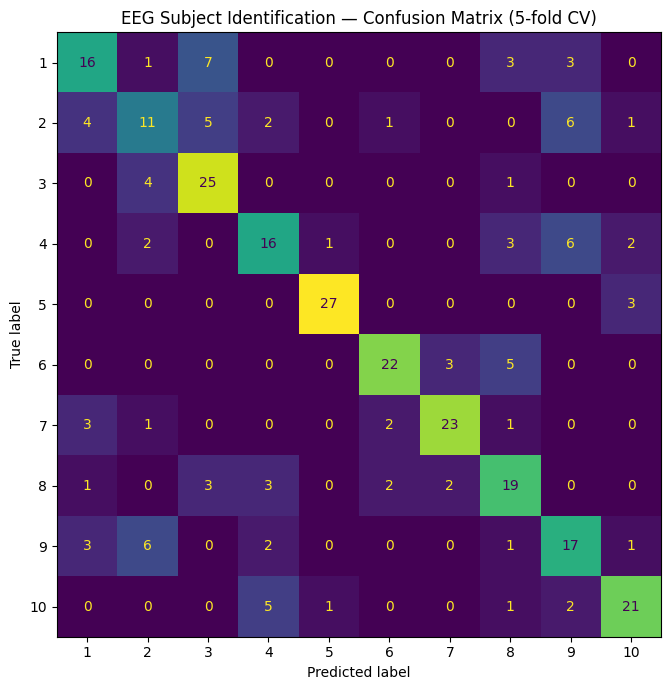

In [12]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Get out-of-fold predictions (each sample predicted only by a model that didn't see it)
y_pred = cross_val_predict(model, X, y, cv=cv)

labels = np.sort(np.unique(y))
cm = confusion_matrix(y, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap=None, colorbar=False)
plt.title("EEG Subject Identification — Confusion Matrix (5-fold CV)")
plt.tight_layout()
plt.savefig("../figures/confusion_matrix.png", dpi=200)
plt.show()


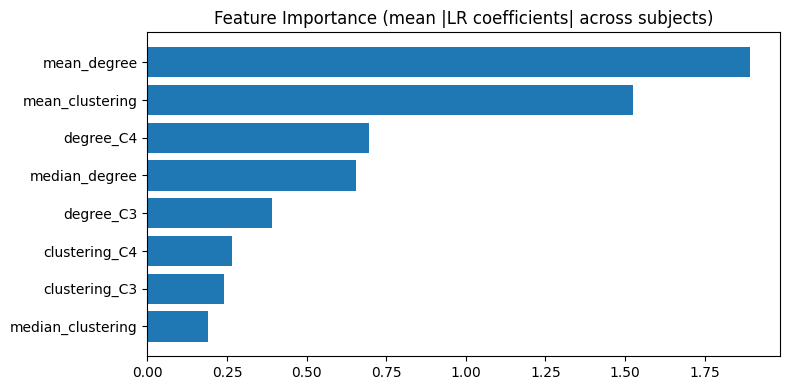

,feature,importance
3,median_clustering,0.189143
5,clustering_C3,0.241152
7,clustering_C4,0.266867
4,degree_C3,0.391173
1,median_degree,0.653646
6,degree_C4,0.697073
2,mean_clustering,1.526237
0,mean_degree,1.892024


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Fit once on all data (for interpretation only)
model.fit(X, y)

# Extract the logistic regression step
lr = model.named_steps["clf"]

# Coefficients: shape = (n_classes, n_features)
coefs = lr.coef_

# Aggregate importance across subjects
importance = np.mean(np.abs(coefs), axis=0)

imp_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importance
}).sort_values("importance", ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(imp_df["feature"], imp_df["importance"])
ax.set_title("Feature Importance (mean |LR coefficients| across subjects)")
plt.tight_layout()
plt.savefig("../figures/feature_weights.png", dpi=200)
plt.show()

imp_df


In [15]:
import numpy as np
import pandas as pd
import mne
from mne.datasets import eegbci
from mne_connectivity import spectral_connectivity_epochs

def extract_features_for_subject_run(subj, run_id):
    """
    Returns a DataFrame with one row per epoch for a given subject+run.
    Uses your current pipeline: preprocess -> epoch -> per-epoch coherence -> top-k graph features.
    """

    fnames = eegbci.load_data(subj, runs=[run_id])
    raw = mne.io.read_raw_edf(fnames[0], preload=True, verbose=False)

    raw.rename_channels(lambda x: x.strip("."))
    eegbci.standardize(raw)
    raw.set_montage("standard_1020", on_missing="ignore")

    raw.filter(l_freq, h_freq, fir_design="firwin", verbose=False)
    raw.set_eeg_reference("average", verbose=False)

    picks = mne.pick_types(raw.info, eeg=True, exclude="bads")
    raw.pick(picks)

    epochs = mne.make_fixed_length_epochs(
        raw, duration=epoch_len, overlap=0.0, preload=True, verbose=False
    )

    n_ch = len(epochs.ch_names)
    full_size = n_ch * n_ch

    rows_local = []
    for ep_i in range(len(epochs)):
        ep = epochs[ep_i:ep_i+1]

        con = spectral_connectivity_epochs(
            ep,
            method=method,
            mode=mode,
            sfreq=ep.info["sfreq"],
            fmin=alpha_band[0],
            fmax=alpha_band[1],
            faverage=True,
            verbose=False,
        )

        conn_raw = np.asarray(con.get_data(output="compact"))
        conn_raw = np.squeeze(conn_raw)

        if conn_raw.size != full_size:
            raise ValueError(
                f"Unexpected compact size for subject {subj}, run {run_id}, epoch {ep_i}: "
                f"got {conn_raw.size}, expected {full_size}"
            )

        mat = conn_raw.reshape(n_ch, n_ch)
        np.fill_diagonal(mat, 0.0)
        mat = 0.5 * (mat + mat.T)

        feats = topk_graph_features(mat, epochs.ch_names, top_k=top_k)
        feats["subject"] = subj
        feats["epoch_idx"] = ep_i
        feats["run_id"] = run_id
        rows_local.append(feats)

    return pd.DataFrame(rows_local)


In [16]:
train_run = 1  # rest eyes open
test_run = 3   # motor imagery (common choice in EEGBCI)

dfs_train = []
dfs_test = []

for subj in subjects:
    print(f"Subject {subj}: extracting Run {train_run} (train) ...")
    dfs_train.append(extract_features_for_subject_run(subj, train_run))

    print(f"Subject {subj}: extracting Run {test_run} (test) ...")
    dfs_test.append(extract_features_for_subject_run(subj, test_run))

df_train = pd.concat(dfs_train, ignore_index=True)
df_test = pd.concat(dfs_test, ignore_index=True)

print("Train shape:", df_train.shape, " Test shape:", df_test.shape)
print("Train rows per subject:\n", df_train["subject"].value_counts().sort_index())
print("Test rows per subject:\n", df_test["subject"].value_counts().sort_index())

df_train.head()


Subject 1: extracting Run 1 (train) ...
Subject 1: extracting Run 3 (test) ...
Subject 2: extracting Run 1 (train) ...
Subject 2: extracting Run 3 (test) ...


Subject 3: extracting Run 1 (train) ...


Subject 3: extracting Run 3 (test) ...
Subject 4: extracting Run 1 (train) ...


Subject 4: extracting Run 3 (test) ...
Subject 5: extracting Run 1 (train) ...
Subject 5: extracting Run 3 (test) ...


Subject 6: extracting Run 1 (train) ...
Subject 6: extracting Run 3 (test) ...


...

Subject 7: extracting Run 3 (test) ...
Subject 8: extracting Run 1 (train) ...


Subject 8: extracting Run 3 (test) ...
Subject 9: extracting Run 1 (train) ...


Subject 9: extracting Run 3 (test) ...
Subject 10: extracting Run 1 (train) ...
Subject 10: extracting Run 3 (test) ...


Train shape: (300, 11)  Test shape: (613, 11)
Train rows per subject:
 subject
1     30
2     30
3     30
4     30
5     30
6     30
7     30
8     30
9     30
10    30
Name: count, dtype: int64
Test rows per subject:
 subject
1     62
2     61
3     62
4     61
5     61
6     61
7     62
8     61
9     61
10    61
Name: count, dtype: int64


,mean_degree,median_degree,mean_clustering,median_clustering,degree_C3,clustering_C3,degree_C4,clustering_C4,subject,epoch_idx,run_id
0,0.879744,0.470896,0.257812,0.0,0.000000,0.000000,0.000000,0.0,1,0,1
1,0.831659,0.864933,0.226562,0.0,1.329248,0.666667,0.429092,0.0,1,1,1
2,0.863835,0.461869,0.240104,0.0,0.447678,0.000000,0.000000,0.0,1,2,1
3,0.862400,0.892402,0.277232,0.0,0.441611,0.000000,0.457005,0.0,1,3,1
4,0.867363,0.499033,0.221577,0.0,0.445206,0.000000,0.894245,0.0,1,4,1


Generalization accuracy (train Run 1 → test Run 3): 0.618
Chance baseline: 0.100


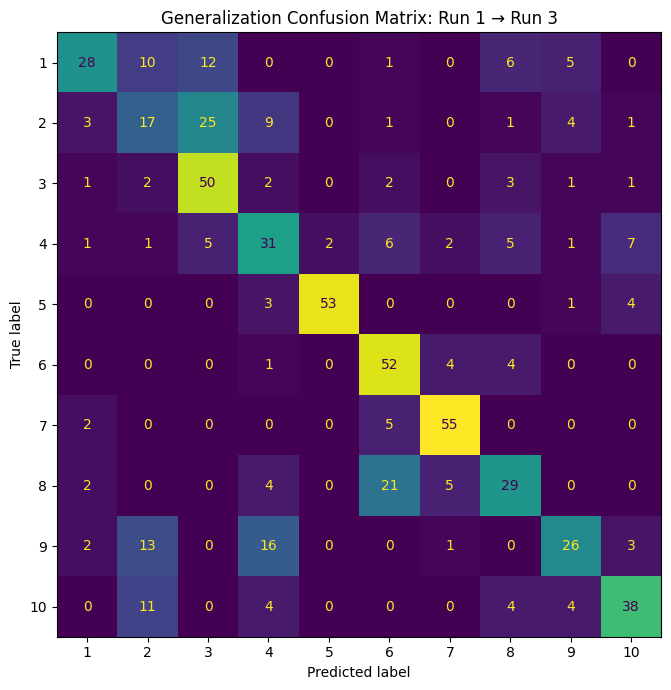

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

feature_cols = [c for c in df_train.columns if c not in ["subject", "epoch_idx", "run_id"]]

X_train = df_train[feature_cols].to_numpy()
y_train = df_train["subject"].to_numpy()

X_test = df_test[feature_cols].to_numpy()
y_test = df_test["subject"].to_numpy()

model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, solver="lbfgs"))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Generalization accuracy (train Run {train_run} → test Run {test_run}): {acc:.3f}")
print(f"Chance baseline: {1 / len(np.unique(y_train)):.3f}")

labels = np.sort(np.unique(y_train))
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap=None, colorbar=False)
plt.title(f"Generalization Confusion Matrix: Run {train_run} → Run {test_run}")
plt.tight_layout()
plt.savefig("../figures/confusion_matrix_generalization.png", dpi=200)
plt.show()
